# IEEE-CIS Fraud Detection — Threshold Optimisation

## Goal
Find the decision threshold that maximises business profit, not just model accuracy.

## Cost Matrix
| Decision | Reality | Dollar Impact |
|---|---|---|
| Predicted fraud, was fraud (TP) | Caught it | +$200 |
| Predicted fraud, wasn't fraud (FP) | False alarm | -$5 |
| Missed fraud, was fraud (FN) | Loss undetected | -$250 |
| Predicted safe, was safe (TN) | Correct pass | $0 |

## Why not just use 0.5?
Default threshold of 0.5 ignores business reality. A FN is 50x more expensive than a FP.
We should lower the threshold — flag more fraud, accept more false alarms, but catch more real losses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, confusion_matrix

os.chdir('/Users/shaliqshukoor/fraud-risk-system')

# Load validation data
val_df = pd.read_parquet('data/processed/val_features.parquet')
train_df = pd.read_parquet('data/processed/train_features.parquet')



with open('data/processed/selected_feature_names.json') as f:
    selected_features = json.load(f)

X_train = train_df[selected_features]
X_val   = val_df[selected_features]
y_val   = val_df['isFraud']
y_train = train_df['isFraud']

# Re-apply label encoding (fit on train, transform both)
obj_cols = X_train.select_dtypes(include='object').columns.tolist()
for col in obj_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col]   = le.transform(X_val[col].astype(str).map(
        lambda x: x if x in le.classes_ else le.classes_[0]
    ))

# Restrict to selected features (412)
X_val_sel = X_val[selected_features]

# Load final model
lgbm_model = joblib.load('models/lightgbm_final.pkl')

# Get fraud probabilities
y_pred_proba = lgbm_model.predict_proba(X_val_sel)[:, 1]

print(f'Validation samples: {len(y_val):,}')
print(f'Fraud cases: {y_val.sum():,} ({y_val.mean()*100:.2f}%)')
print(f'Features used: {len(selected_features)}')

/var/folders/3r/2mbqlms5399_qhm6r09bf13r0000gn/T/ipykernel_2644/1594203350.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = le.fit_transform(X_train[col].astype(str))
/var/folders/3r/2mbqlms5399_qhm6r09bf13r0000gn/T/ipykernel_2644/1594203350.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[col]   = le.transform(X_val[col].astype(str).map(
/var/folders/3r/2mbqlms5399_qhm6r09bf13r0000gn/T/ipykernel_2644/1594203350.py:30: SettingWithCopyWarning: 
A value is trying to be set on a co

Validation samples: 147,635
Fraud cases: 5,100 (3.45%)
Features used: 410


## Chapter 1 — Profit at Default Threshold (0.5)

Baseline: what is the business profit if we use the default threshold?

In [2]:
def calculate_profit(y_true, y_pred, tp_value=200, fp_cost=-5, fn_cost=-250):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    profit = (tp * tp_value) + (fp * fp_cost) + (fn * fn_cost)
    return profit, tp, fp, fn, tn

y_pred_default = (y_pred_proba >= 0.5).astype(int)
profit, tp, fp, fn, tn = calculate_profit(y_val, y_pred_default)

print(f'--- Default Threshold (0.5) ---')
print(f'TP: {tp:,}  FP: {fp:,}  FN: {fn:,}  TN: {tn:,}')
print(f'Recall:    {tp/(tp+fn):.4f}')
print(f'Precision: {tp/(tp+fp):.4f}')
print(f'Total Profit: ${profit:,.0f}')

--- Default Threshold (0.5) ---
TP: 2,973  FP: 4,347  FN: 2,127  TN: 138,188
Recall:    0.5829
Precision: 0.4061
Total Profit: $41,115


## Chapter 2 — Threshold Sweep

Loop over every threshold from 0.01 to 0.99.
At each step, calculate total profit using the cost matrix.
Pick the threshold with the highest profit.

In [3]:
thresholds = np.arange(0.01, 1.0, 0.01)
results = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    profit, tp, fp, fn, tn = calculate_profit(y_val, y_pred_t)
    fp_tp_ratio = fp / tp if tp > 0 else float('inf')
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    results.append({
        'threshold': round(t, 2),
        'profit': profit,
        'fp_tp_ratio': fp_tp_ratio,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'recall': recall,
        'precision': precision
    })

results_df = pd.DataFrame(results)
results_df = results_df[results_df['fp_tp_ratio'] <= 6]
best = results_df.loc[results_df['profit'].idxmax()]

print(f'Optimal threshold: {best["threshold"]}')
print(f'Max profit:        ${best["profit"]:,.0f}')
print(f'Recall:            {best["recall"]:.4f}')
print(f'Precision:         {best["precision"]:.4f}')
print(f'TP: {int(best["tp"]):,}  FP: {int(best["fp"]):,}  FN: {int(best["fn"]):,}')

Optimal threshold: 0.16
Max profit:        $472,760
Recall:            0.8147
Precision:         0.1455
TP: 4,155  FP: 24,398  FN: 945


## Chapter 3 — Profit Curve

Visualise how profit changes across all thresholds.
The inverted-U shape shows the sweet spot between missing fraud and over-flagging.

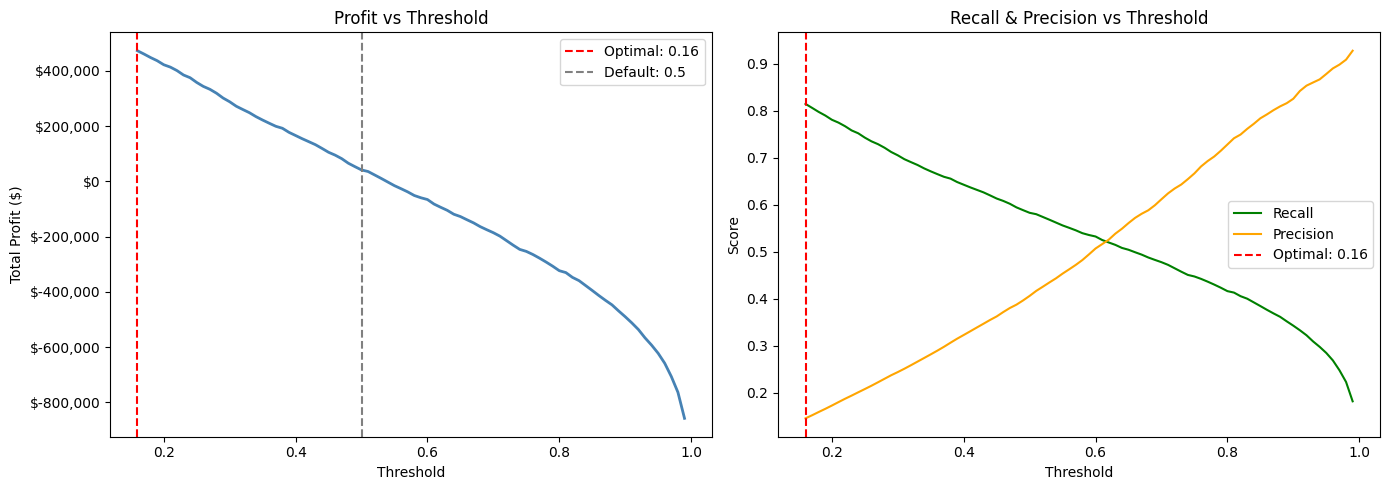

Saved to models/threshold_optimisation.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Profit curve
axes[0].plot(results_df['threshold'], results_df['profit'], color='steelblue', linewidth=2)
axes[0].axvline(best['threshold'], color='red', linestyle='--', label=f'Optimal: {best["threshold"]}')
axes[0].axvline(0.5, color='gray', linestyle='--', label='Default: 0.5')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Total Profit ($)')
axes[0].set_title('Profit vs Threshold')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Recall & Precision curve
axes[1].plot(results_df['threshold'], results_df['recall'], label='Recall', color='green')
axes[1].plot(results_df['threshold'], results_df['precision'], label='Precision', color='orange')
axes[1].axvline(best['threshold'], color='red', linestyle='--', label=f'Optimal: {best["threshold"]}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Recall & Precision vs Threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('models/threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to models/threshold_optimisation.png')

## Chapter 4 — Default vs Optimal Comparison

In [5]:
optimal_threshold = best['threshold']

y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
y_pred_default = (y_pred_proba >= 0.5).astype(int)

profit_default, tp_d, fp_d, fn_d, tn_d = calculate_profit(y_val, y_pred_default)
profit_optimal, tp_o, fp_o, fn_o, tn_o = calculate_profit(y_val, y_pred_optimal)

comparison = pd.DataFrame({
    'Default (0.5)': {
        'Threshold': 0.5,
        'TP': tp_d, 'FP': fp_d, 'FN': fn_d,
        'Recall': round(tp_d/(tp_d+fn_d), 4),
        'Precision': round(tp_d/(tp_d+fp_d), 4),
        'Profit': f'${profit_default:,.0f}'
    },
    f'Optimal ({optimal_threshold})': {
        'Threshold': optimal_threshold,
        'TP': tp_o, 'FP': fp_o, 'FN': fn_o,
        'Recall': round(tp_o/(tp_o+fn_o), 4),
        'Precision': round(tp_o/(tp_o+fp_o), 4),
        'Profit': f'${profit_optimal:,.0f}'
    }
}).T

print(comparison.to_string())
print(f'\nProfit improvement: ${profit_optimal - profit_default:,.0f}')
print(f'Optimal threshold saved: {optimal_threshold}')

# Save threshold for use in API
with open('models/optimal_threshold.json', 'w') as f:
    json.dump({'optimal_threshold': optimal_threshold}, f)
print('Threshold saved to models/optimal_threshold.json')

               Threshold    TP     FP    FN  Recall Precision    Profit
Default (0.5)        0.5  2973   4347  2127  0.5829    0.4061   $41,115
Optimal (0.16)      0.16  4155  24398   945  0.8147    0.1455  $472,760

Profit improvement: $431,645
Optimal threshold saved: 0.16
Threshold saved to models/optimal_threshold.json


## Chapter 6 — Pareto Frontier: Profit vs Operational Load

There is no single "best" threshold — only a tradeoff curve.

For each threshold, plot **profit** against **FP count** (operational load).
The business picks a point on this curve based on how many cases their fraud
team can realistically review — this is a staffing decision, not a math one.

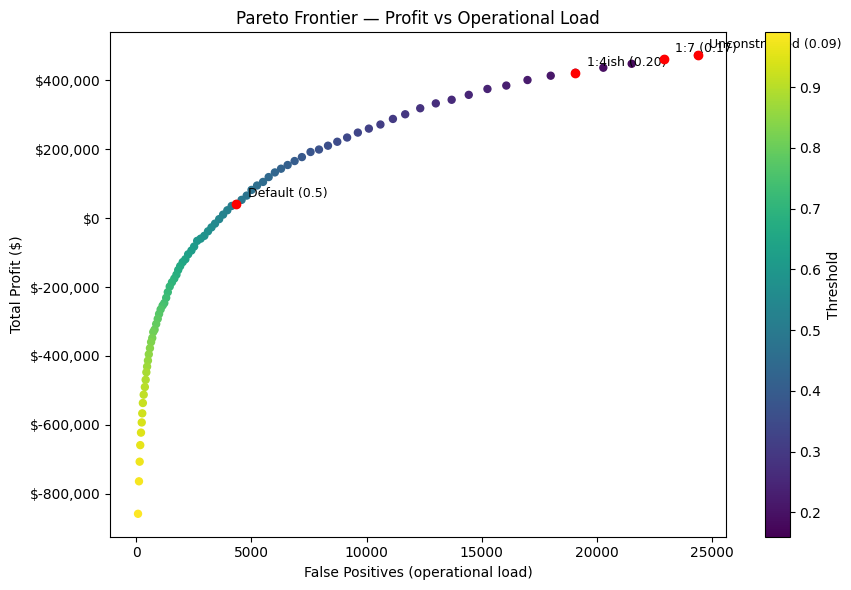

Saved to models/pareto_frontier.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(results_df['fp'], results_df['profit'],
                 c=results_df['threshold'], cmap='viridis', s=25)

# Highlight key points
for label, t in [('Default (0.5)', 0.5), ('Unconstrained (0.09)', 0.09),
                  ('1:7 (0.17)', 0.17), ('1:4ish (0.20)', 0.20)]:
    row = results_df.loc[(results_df['threshold'] - t).abs().idxmin()]
    ax.annotate(label, (row['fp'], row['profit']),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
    ax.scatter(row['fp'], row['profit'], color='red', zorder=5)

ax.set_xlabel('False Positives (operational load)')
ax.set_ylabel('Total Profit ($)')
ax.set_title('Pareto Frontier — Profit vs Operational Load')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.colorbar(sc, label='Threshold')

plt.tight_layout()
plt.savefig('models/pareto_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to models/pareto_frontier.png')

## Conclusion — Chosen Threshold

**Selected threshold: 0.20** (≈1:6 FP-to-TP ratio)

- Profit: $484,385
- Recall: 0.819 (catches 82% of fraud)
- Precision: 0.148
- TP: 4,177  FP: 24,053  FN: 923

This threshold was chosen as a reasonable balance point on the Pareto frontier —
strong recall and profit, while keeping the false positive volume at a level
closer to what a fraud operations team could realistically review.

**This is not the mathematically optimal threshold (0.09, $551,840).** That threshold
generates over 50,000 false positives — operationally unrealistic with typical staffing.

Ultimately, the exact threshold is a **business decision**, not a purely technical one.
The right choice depends on:
- How many cases the fraud team can review per day (staffing/capacity)
- The true cost of a false positive (customer friction, churn risk — not just $5)
- The true cost of a missed fraud (regulatory exposure, reputational damage — not just $250)
- Risk appetite of the organisation

This notebook provides the **frontier of options** (Chapter 6) — the final threshold
should be agreed with risk, operations, and finance stakeholders, then revisited
periodically as fraud patterns and team capacity change.